# ĐỒ ÁN 2: DATA FITTING VÀ PHƯƠNG PHÁP OLS
### PHẦN 2: ỨNG DỤNG DATA FITTING VÀO DỮ LIỆU THỰC TẾ

* **Môn học:** Toán Ứng Dụng và Thống Kê
* **Mã môn:** MTH00051
* **Học kỳ:** Học kỳ 2, Năm học 2025 - 2026
* **Giảng viên lý thuyết:** ThS. Võ Nam Thục Đoan, ThS. Lê Nhựt Nam
* **Nhóm thực hiện:** Nhóm 14

---

**Mục tiêu:**
* Minh họa quy trình tiền xử lý và phân tích một bộ dữ liệu môi trường thực tế;
* Xây dựng và đánh giá các mô hình hồi quy tuyến tính từ đầu (OLS, Ridge, Lasso);
* Tạo tài liệu tham khảo để hiểu rõ cách áp dụng các kỹ thuật `data fitting` nhằm giải quyết các bài toán thực tiễn.

## 1. Khởi tạo môi trường và Import các hàm tiện ích



In [21]:

# Import thư viện cơ bản
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
import json

# Cấu hình đường dẫn để import các module từ thư mục cha
current_dir = os.getcwd()
sys.path.append(os.path.abspath(os.path.join(current_dir, "..")))

# Import các module tự xây dựng
from data_pipeline import EDAToolkit, DataPipeline  # Khám phá & tiền xử lý dữ liệu
from part1.ols_implementation import ols_fit, model_metrics, vif  # OLS cơ bản
from part1.ridge_lasso import ridge_fit, lasso_fit  # Hồi quy điều chuẩn L2/L1
from part1.cross_validation import kfold_cv  # K-Fold Cross-Validation
from part1.residual_analysis import residual_diagnostics  # Phân tích phần dư
from model_comparison import ModelComparator  # So sánh nhiều mô hình
from config import RANDOM_STATE  # Hạt ngẫu nhiên cố định cho tái tạo kết quả
from advanced_methods import KernelRidgeRegression, sample_rows

## 2. Mô tả bộ dữ liệu

**Bài toán hướng đến:** Trong thực tế, các máy phân tích khí độc hóa học chuẩn tham chiếu thường rất đắt tiền và khó triển khai trên diện rộng, trong khi các cảm biến oxit kim loại tự động hóa lại rẻ tiền và dễ lắp đặt nhưng độ chính xác thô thấp hơn. Nhóm chúng em hướng đến bài toán: **Xây dựng mô hình toán học sử dụng phản hồi từ các cảm biến hóa học đo được trong không khí (PT08.S1 - PT08.S5) cùng các yếu tố khí hậu (Nhiệt độ, Độ ẩm) để dự đoán chính xác nồng độ của khí độc hại Carbon Monoxide (CO) `CO(GT)`**.

Đây là một ví dụ điển hình của bài toán `data fitting`, mục tiêu là tìm ra một hàm số hồi quy đa biến phù hợp nhất để mô tả mối quan hệ giữa biến đầu ra ($y$: Nồng độ khí Carbon Monoxide (CO) thực tế) và các biến đầu vào ($X$: Các đặc trưng từ hệ thống cảm biến).

**Quy ước:** Mức ý nghĩa áp dụng cho các kiểm định thống kê trong đồ án: $\alpha = 0.05$

*Lưu ý về dữ liệu:* Trong bộ dữ liệu gốc từ UCI, các giá trị bị thiếu (missing values) được hệ thống tự động mã hóa bằng giá trị `-200`. Do đó, trước khi tiến hành EDA, ta cần chuyển đổi toàn bộ các giá trị `-200` này về định dạng `NaN` chuẩn để không làm lệch các thống kê mô tả.

## 3. Khảo sát dữ liệu



In [22]:
# Đường dẫn tệp dữ liệu
file_path = "data/AirQualityUCI.csv"
target_col = "CO(GT)"  # Biến mục tiêu: Nồng độ CO thực tế (gt = ground truth)

# Tải dữ liệu thô và lấy thống kê sơ bộ
# Lưu ý: EDAToolkit tự động chuyển -200 thành NaN (missing values)
raw_stats = EDAToolkit.get_raw_data_summary(file_path, target_col)

df_raw = raw_stats['df']

# In ra các thông tin tổng quan
print("=== THÔNG TIN BỘ DỮ LIỆU SAU KHI LOAD ===")
print(f"Số lượng mẫu (n): {raw_stats['n_samples']} quan trắc")
print(f"Số lượng đặc trưng (p): {raw_stats['p_features']} biến")
print(f"Target: {raw_stats['target']}")
print(f"Tổng số giá trị Missing: {raw_stats['total_missing']}")

# Thống kê mô tả: mean, std, min, max, quartiles
print("\n=== BẢNG THỐNG KÊ MÔ TẢ TỔNG QUAN ===")
display(EDAToolkit.descriptive_statistics_report(df_raw))

# Báo cáo chi tiết về giá trị bị thiếu (%) theo từng cột
print("\n=== BÁO CÁO GIÁ TRỊ BỊ THIẾU (MISSING VALUES) ===")
display(EDAToolkit.missing_report(df_raw))

# Kiểm tra dữ liệu trùng lặp (duplicate rows)
print("\n=== KIỂM TRA DỮ LIỆU TRÙNG LẶP ===")
EDAToolkit.check_duplicates(df_raw);

=== THÔNG TIN BỘ DỮ LIỆU SAU KHI LOAD ===
Số lượng mẫu (n): 9357 quan trắc
Số lượng đặc trưng (p): 15 biến
Target: CO(GT)
Tổng số giá trị Missing: 16244

=== BẢNG THỐNG KÊ MÔ TẢ TỔNG QUAN ===


,Count,Mean,Std Dev,Min,Q1 (25%),Median (Q2),Q3 (75%),Max
CO(GT),7765.0,2.13,1.46,0.00,1.00,1.8,2.90,11.90
PT08.S1(CO),8991.0,1099.83,217.08,647.00,937.00,1063.0,1231.00,2040.00
NMHC(GT),914.0,218.81,204.46,7.00,67.00,150.0,297.00,1189.00
C6H6(GT),9357.0,9.69,7.56,0.00,4.00,7.9,13.60,63.70
PT08.S2(NMHC),8991.0,939.15,266.83,383.00,734.50,909.0,1116.00,2214.00
NOx(GT),7718.0,246.90,212.98,2.00,98.00,180.0,326.00,1479.00
PT08.S3(NOx),8991.0,835.49,256.82,322.00,658.00,806.0,969.50,2683.00
NO2(GT),7715.0,113.09,48.37,2.00,78.00,109.0,142.00,340.00
PT08.S4(NO2),8991.0,1456.26,346.21,551.00,1227.00,1463.0,1674.00,2775.00
PT08.S5(O3),8991.0,1022.91,398.48,221.00,731.50,963.0,1273.50,2523.00



=== BÁO CÁO GIÁ TRỊ BỊ THIẾU (MISSING VALUES) ===


,Đặc trưng,Số lượng thiếu,Tỷ lệ thiếu (%)
1,NMHC(GT),8443,90.23
2,NO2(GT),1642,17.55
3,NOx(GT),1639,17.52
4,CO(GT),1592,17.01
5,PT08.S3(NOx),366,3.91
6,PT08.S2(NMHC),366,3.91
7,PT08.S1(CO),366,3.91
8,PT08.S5(O3),366,3.91
9,T,366,3.91
10,RH,366,3.91



=== KIỂM TRA DỮ LIỆU TRÙNG LẶP ===
Số dòng dữ liệu trùng lặp phát hiện: 0


**Nhận xét Tổng quan và Missing Values:**
* **Biến `NMHC(GT)`:** Có tỷ lệ giá trị khuyết cực kỳ cao (> 90%), cần được loại bỏ hoàn toàn đặc trưng này khỏi bộ dữ liệu để tránh làm sai lệch mô hình.
* **Biến mục tiêu `CO(GT)` và một số biến nồng độ khí (`NO2(GT)`, `NOx(GT)`):** Có tỷ lệ thiếu khoảng 17%. Đây là một lượng thiếu đáng kể, ta cần áp dụng các phương pháp phù hợp để xử lý thay vì xóa (drop) để bảo toàn thông tin.
* **Các cảm biến PT08 và điều kiện khí hậu (T, RH, AH):** Đều có cùng số lượng giá trị thiếu là 366 (khoảng 3.91%). Điều này gợi ý rằng hệ thống cảm biến có thể đã gặp trục trặc kỹ thuật hoặc mất điện tại một số mốc thời gian chung.

### 3.1. Trực quan hóa phân phối dữ liệu

                                === BIỂU ĐỒ HISTOGRAM PHÂN PHỐI ===                                 


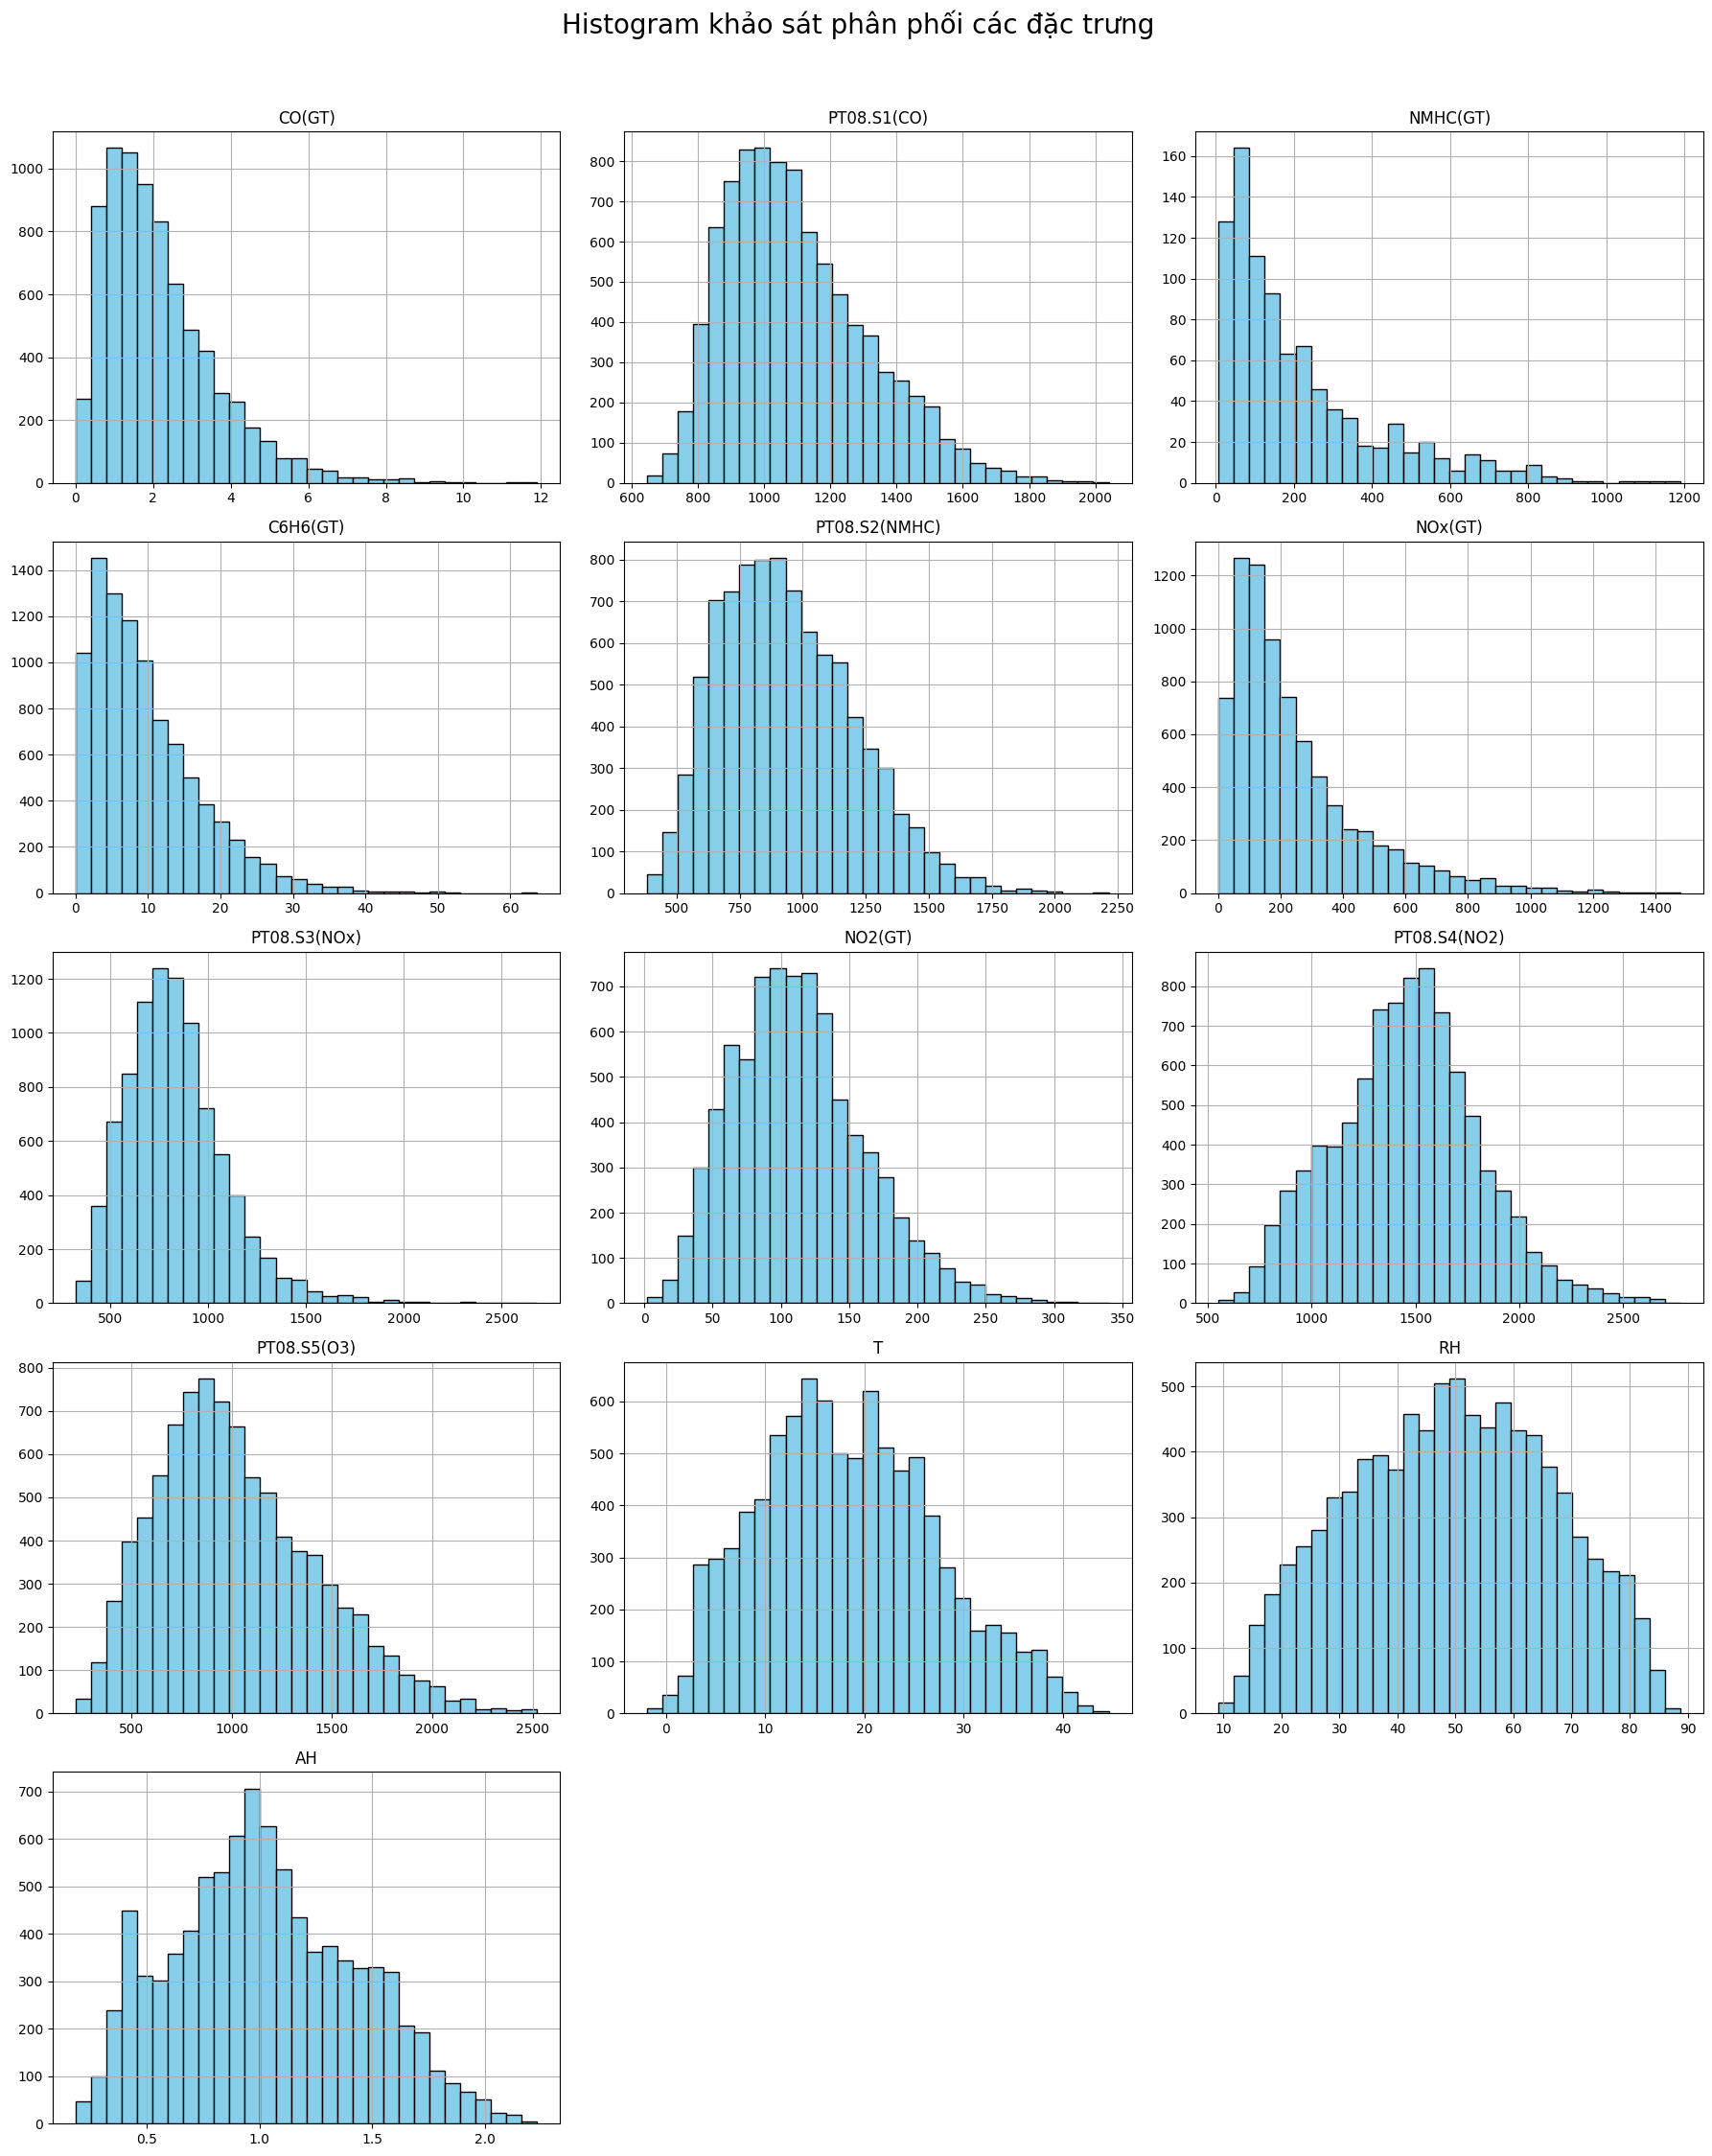

                            === BIỂU ĐỒ BOXPLOT PHÁT HIỆN NGOẠI LAI ===                             


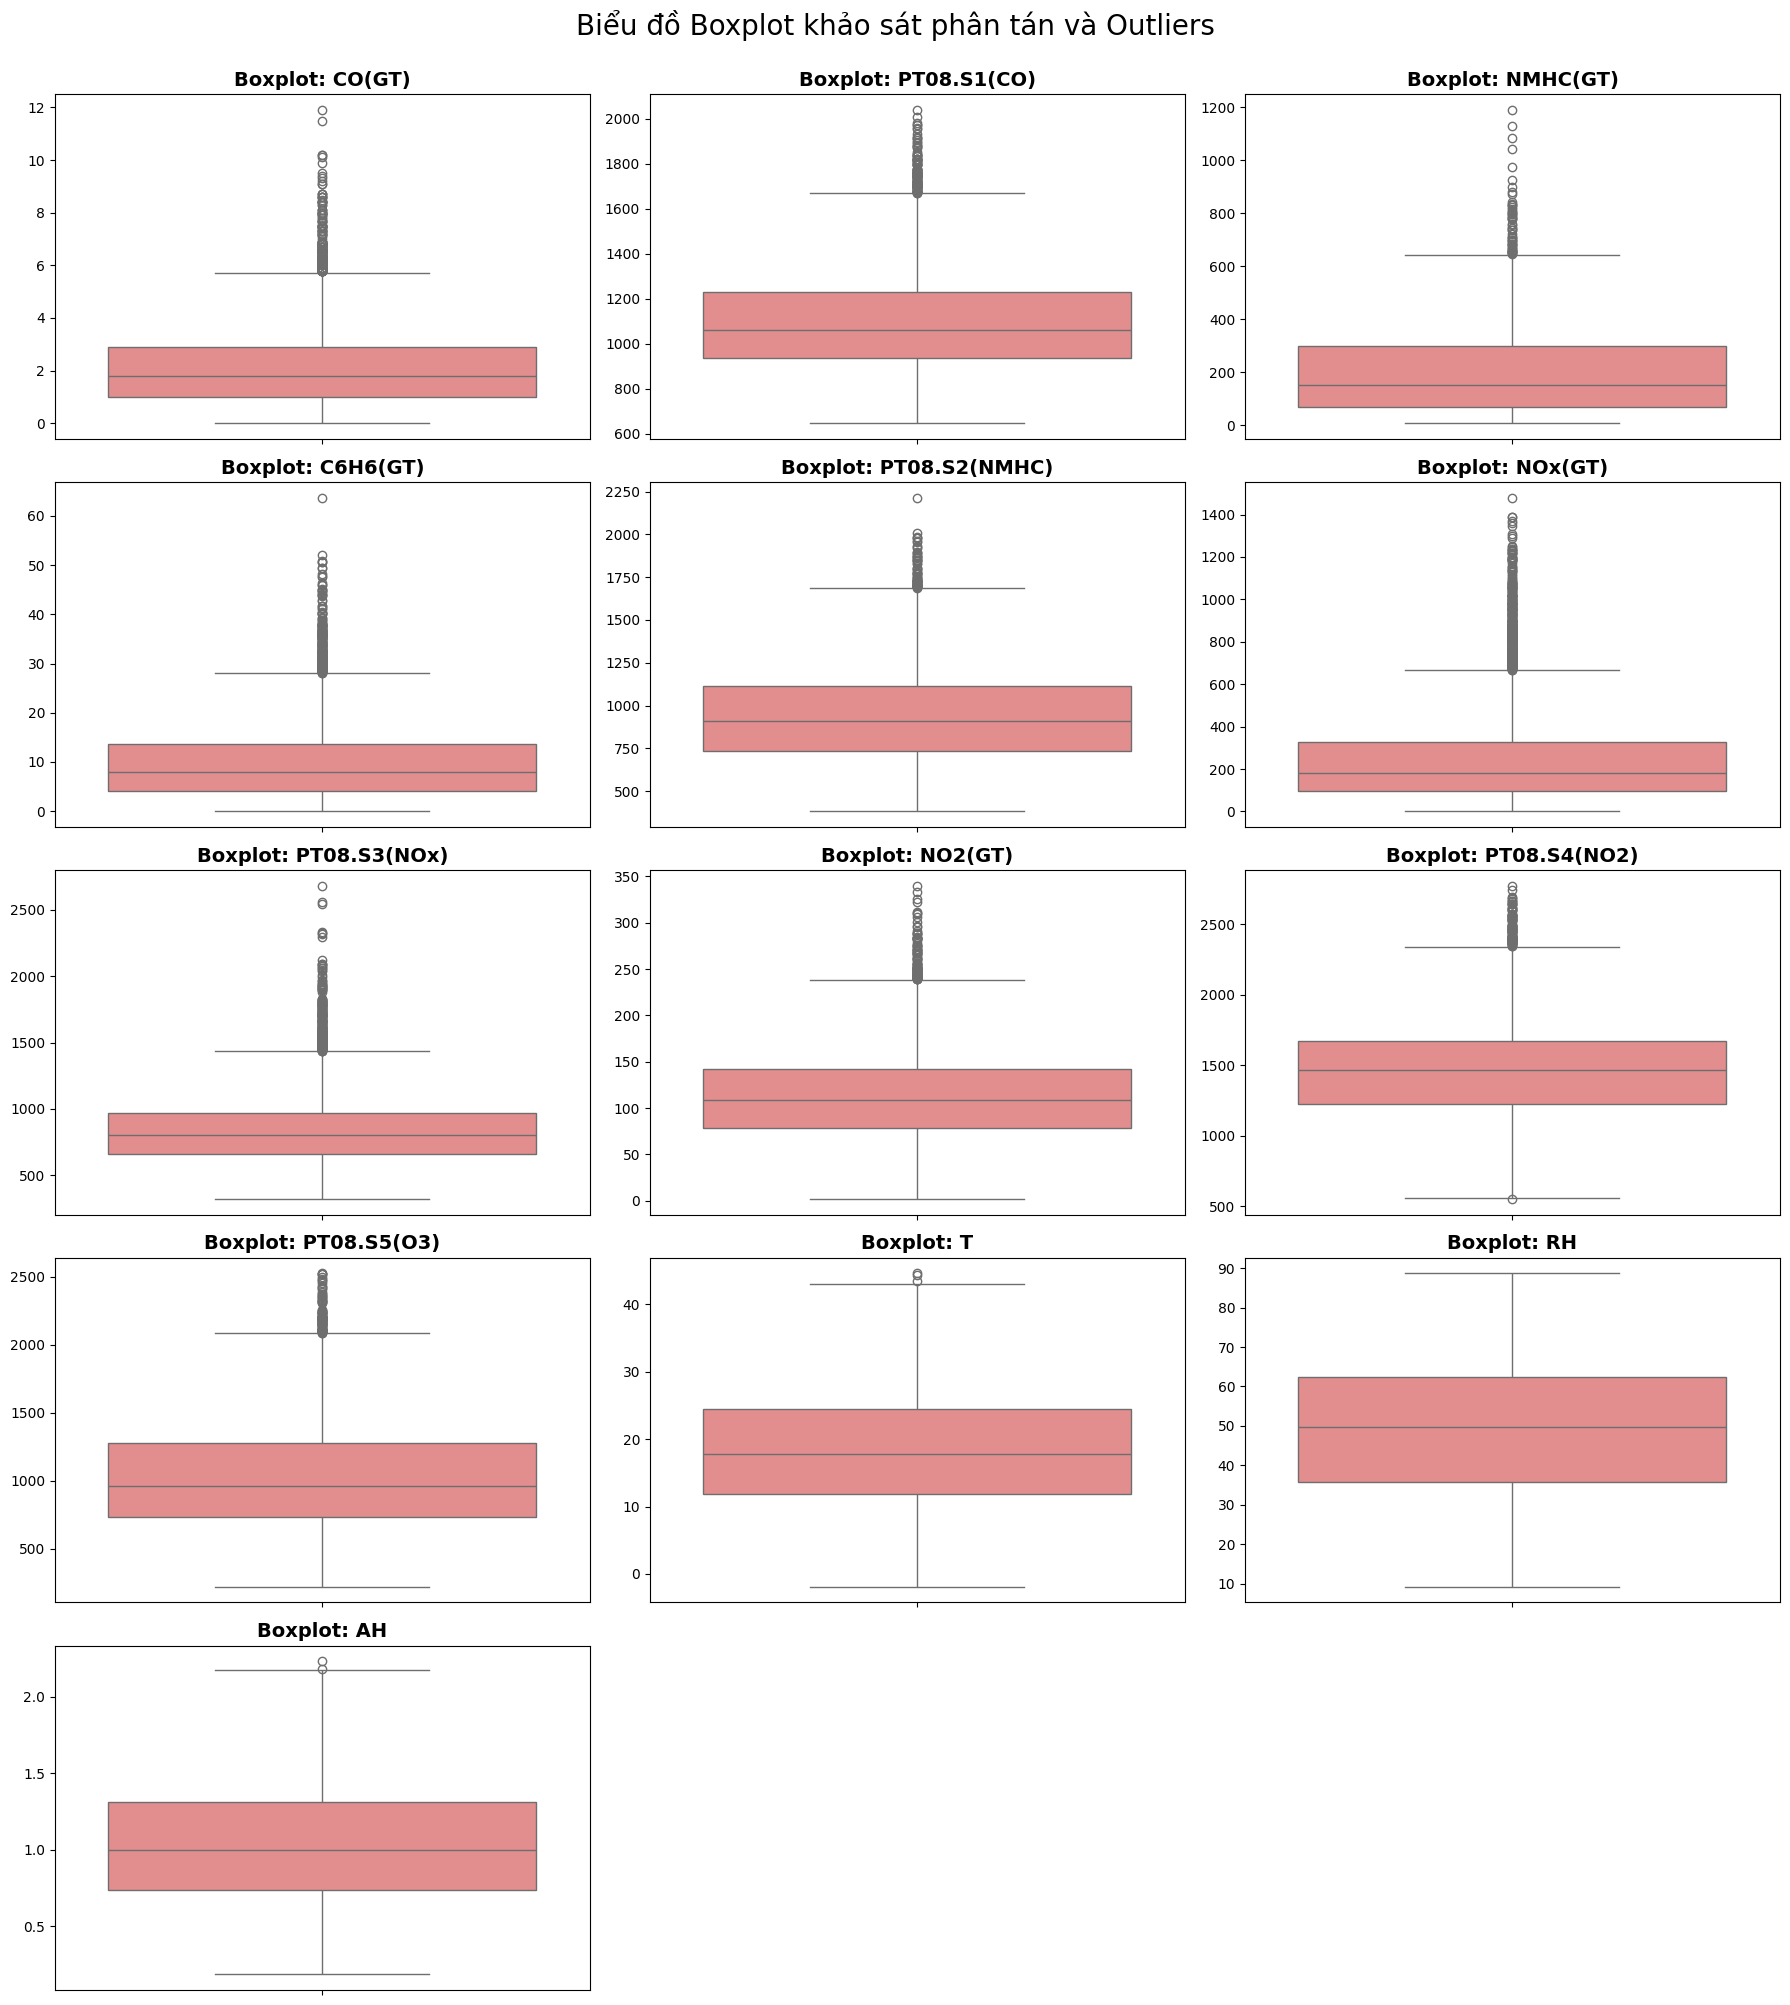

In [23]:

print("=== BIỂU ĐỒ HISTOGRAM PHÂN PHỐI ===".center(100))
EDAToolkit.plot_histograms(df_raw)

print("=== BIỂU ĐỒ BOXPLOT PHÁT HIỆN NGOẠI LAI ===".center(100))
EDAToolkit.plot_boxplots(df_raw)

**Nhận xét Biểu đồ Histogram và Boxplot:**
* **Histogram:** Phần lớn các biến đo nồng độ khí (như CO, NOx, C6H6) đều có phân phối lệch phải (right-skewed) rõ rệt. Ngược lại, các biến về điều kiện môi trường như Nhiệt độ (T), Độ ẩm (RH) có xu hướng phân phối đối xứng và gần với phân phối chuẩn hơn. Sự phân bố lệch phải của các biến khí thải giải thích tại sao phương pháp Z-Score lại bỏ sót nhiều ngoại lai ở bước sau
* **Boxplot:** Có sự xuất hiện của rất nhiều giá trị ngoại lai (outliers) nằm ở phần râu trên của boxplot ở hầu hết các đặc trưng. Đối với các mô hình hồi quy (đặc biệt là phương pháp OLS), sự tồn tại của ngoại lai sẽ có nguy cơ kéo lệch đường hồi quy và làm giảm độ chính xác của dự đoán.

### 3.2. Phân tích tương quan tuyến tính


                          === MA TRẬN TƯƠNG QUAN TUYẾN TÍNH (HEATMAP) ===                           


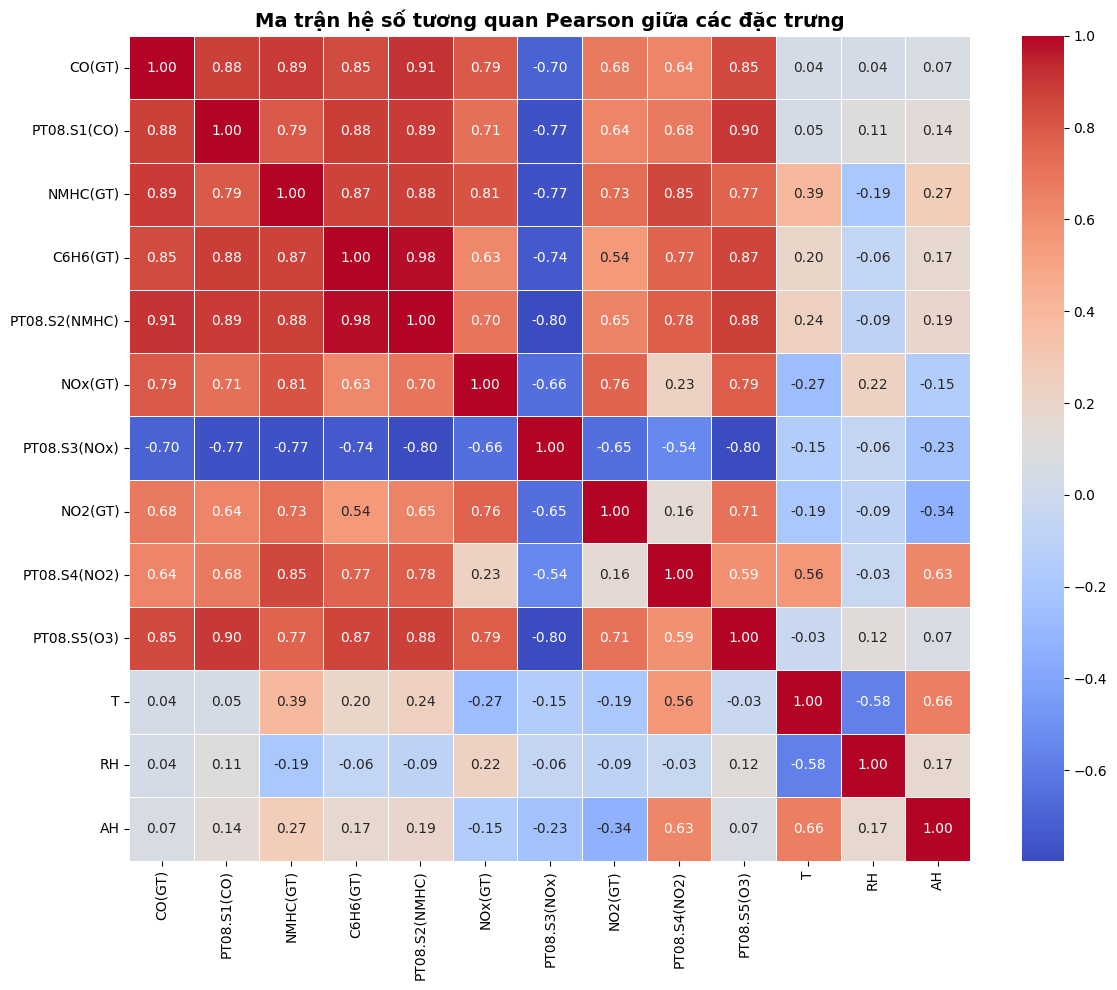

                     === BIỂU ĐỒ SCATTER PLOT (TOP 5 TƯƠNG QUAN MẠNH NHẤT) ===                      


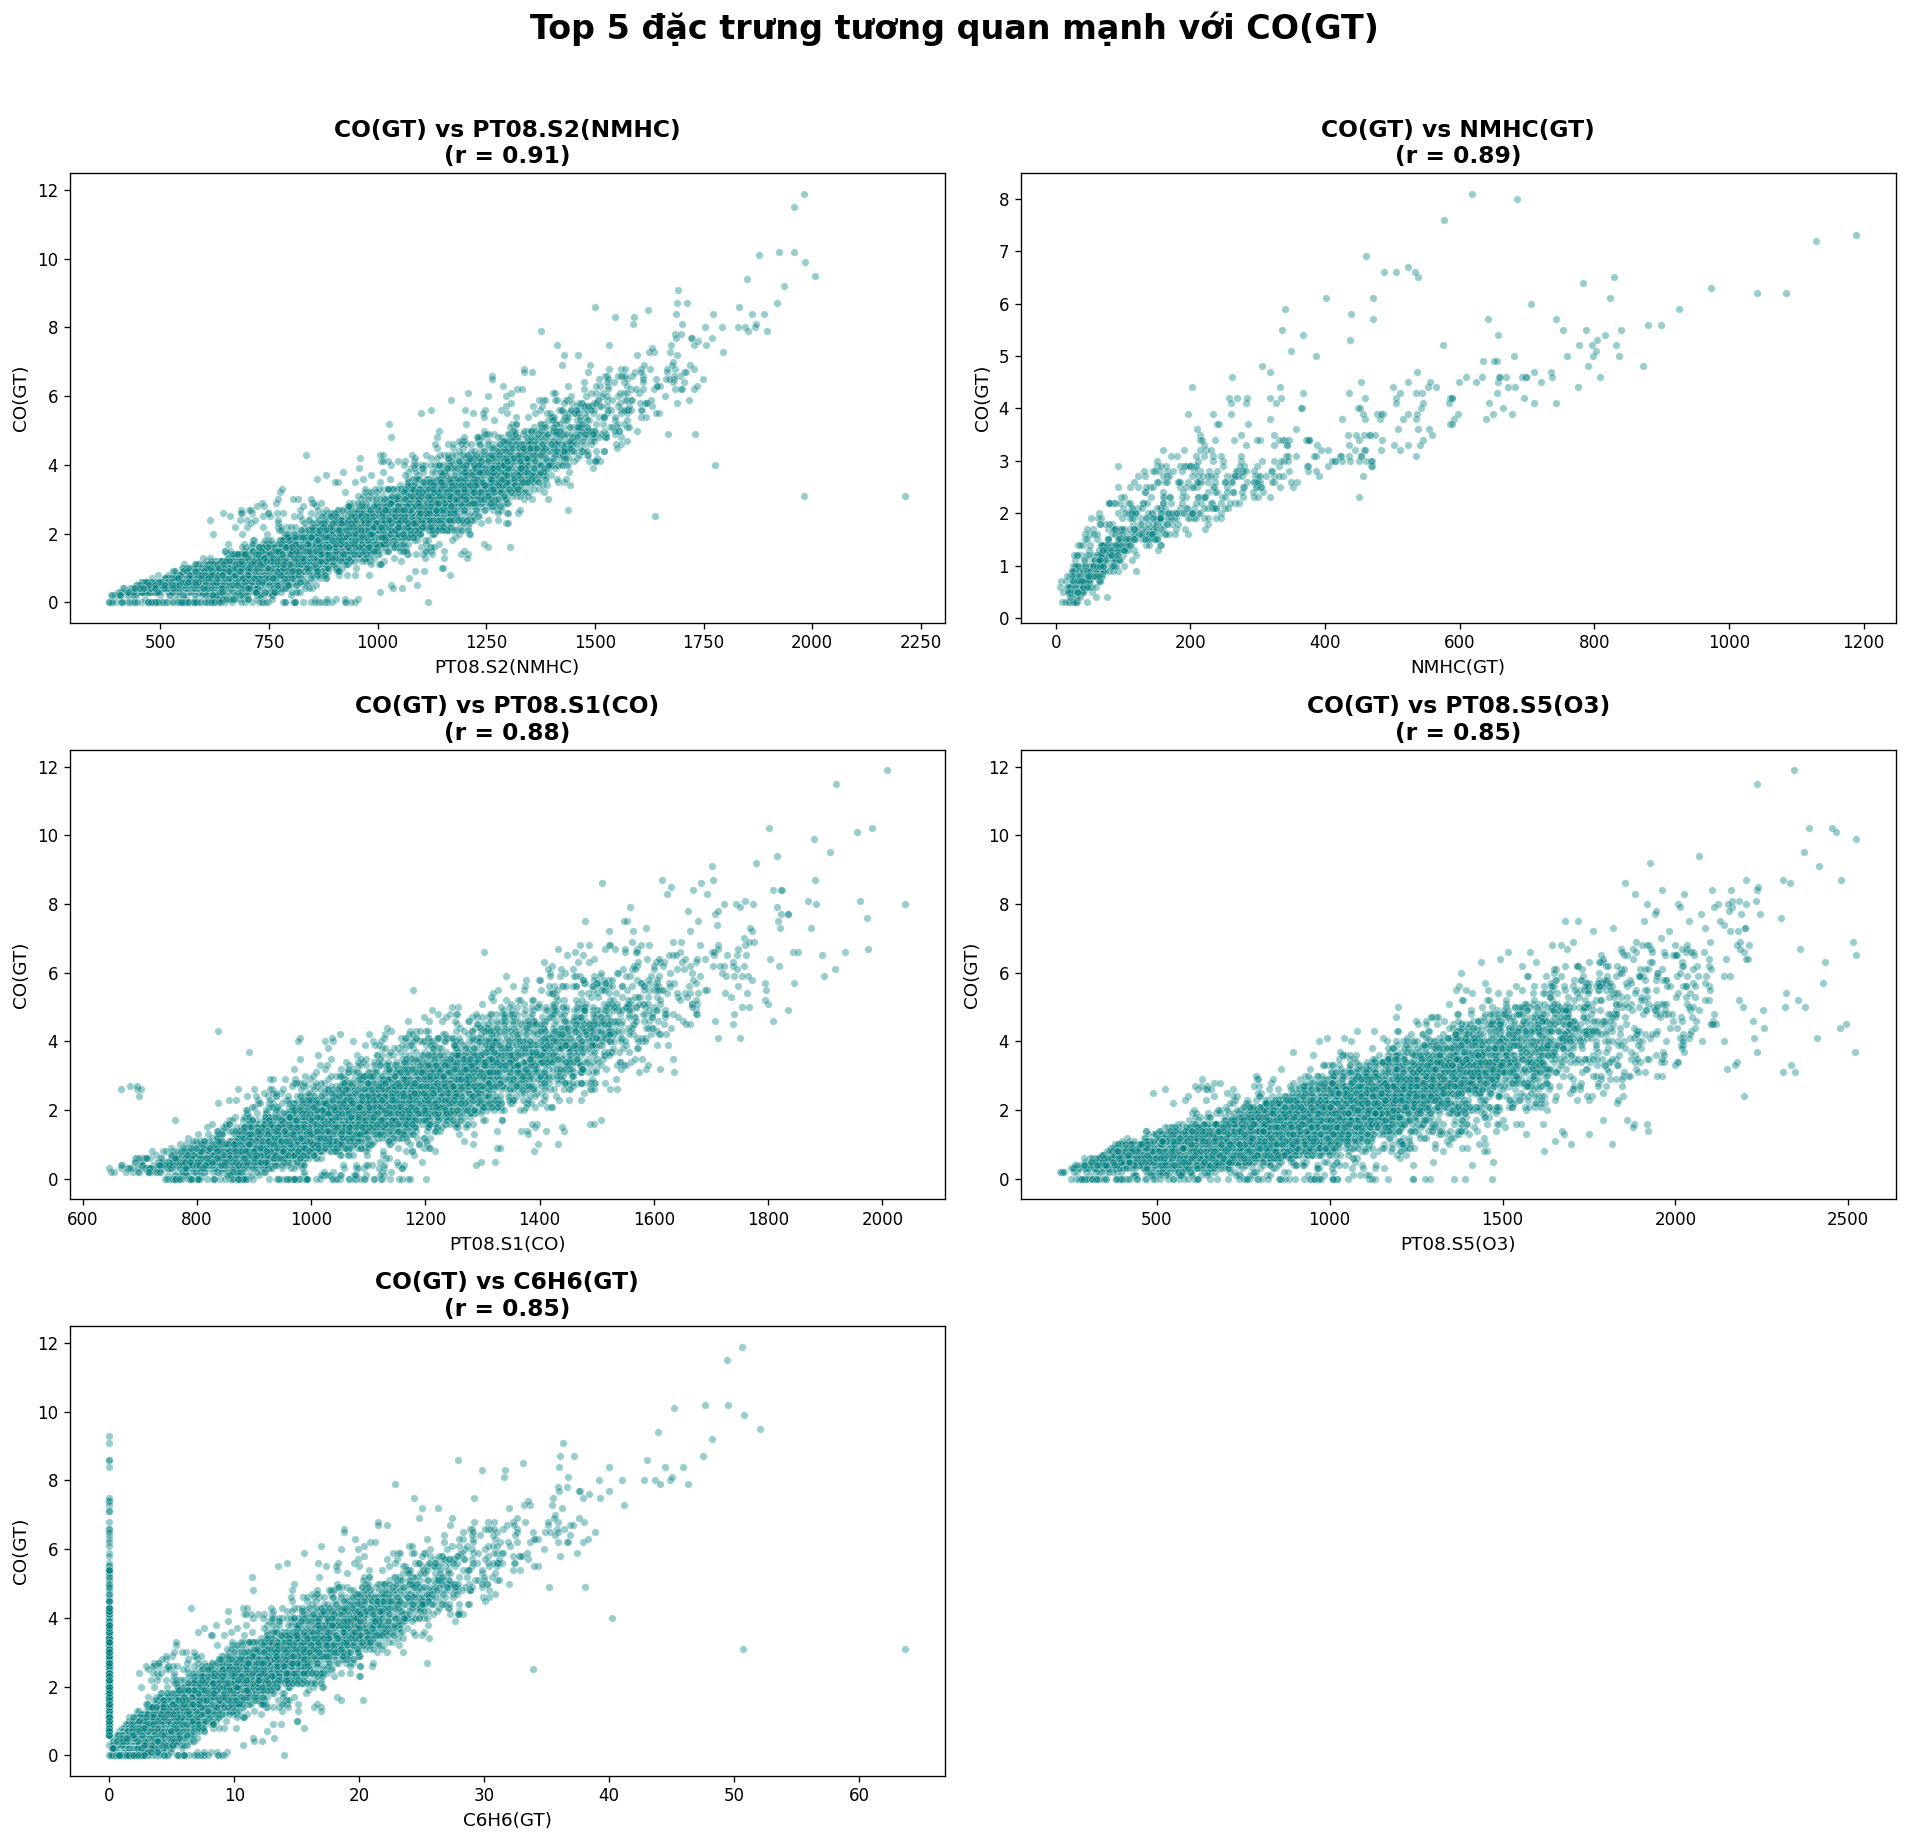

In [24]:
# Vẽ ma trận tương quan (Heatmap)
# → Tìm kiếm: cặp biến nào có tương quan mạnh? Chúng có đa cộng tuyến không?
# → Tương quan mạnh = hình ô vuông tối (đỏ) trong heatmap
print("=== MA TRẬN TƯƠNG QUAN TUYẾN TÍNH (HEATMAP) ===".center(100))
EDAToolkit.plot_correlation_heatmap(df_raw)

# Vẽ scatter plot của Top 5 biến có tương quan mạnh nhất với biến mục tiêu
# → Tìm kiếm: mối quan hệ tuyến tính? Có hiện tượng phương sai thay đổi không?
print("=== BIỂU ĐỒ SCATTER PLOT (TOP 5 TƯƠNG QUAN MẠNH NHẤT) ===".center(100))
EDAToolkit.plot_top_correlations(df_raw, target_col='CO(GT)')

**Nhận xét Ma trận tương quan (Heatmap) và Scatter Plot:**
* **Đa cộng tuyến (Multicollinearity):** Quan sát trên Heatmap cho thấy có sự tương quan tuyến tính rất mạnh giữa nhiều biến độc lập, đặc biệt là trong cụm các cảm biến `PT08.Sx` hoặc giữa `C6H6(GT)` và `PT08.S2(NMHC)`. Trong hồi quy OLS, hiện tượng đa cộng tuyến sẽ làm tăng phương sai của các hệ số hồi quy, khiến mô hình mất tính ổn định. Điều này đòi hỏi phải chọn lọc đặc trưng (Feature Selection) hoặc sử dụng hồi quy có điều chuẩn (Ridge, Lasso).
* **Mối quan hệ với biến mục tiêu `CO(GT)`:** Dựa vào Heatmap và Scatter Plot của top 5 biến tương quan mạnh nhất, ta thấy `CO(GT)` có tương quan dương khá rõ ràng với `C6H6(GT)`, `PT08.S1(CO)`, `PT08.S2(NMHC)`, `PT08.S5(O3)`, và `NOx(GT)`. Khi nồng độ của các chất/chỉ số này tăng, nồng độ CO cũng có xu hướng tăng theo.
* **Sự phân tán của dữ liệu (Scatter Plot):** Ở các mức nồng độ CO cao, dữ liệu có độ phân tán lớn hơn (hình phễu). Điều này cho thấy có khả năng xảy ra hiện tượng phương sai sai số thay đổi (heteroscedasticity) - một giả định quan trọng của OLS cần được kiểm tra sau này.

### 3.3. Đánh giá ngoại lai (Outliers) bằng phương pháp toán học
1. **Phương pháp IQR:** Dựa trên tứ phân vị (Q1, Q3), phù hợp với dữ liệu bị lệch.
2. **Phương pháp Z-Score:** Lọc các giá trị nằm ngoài mốc $|z| > 3$, giả định dữ liệu có phân phối chuẩn.

In [25]:
# Phương pháp IQR (Interquartile Range):
# Ngoại lai = giá trị < Q1 - 1.5*IQR hoặc > Q3 + 1.5*IQR
# Tốt cho dữ liệu bị lệch, không yêu cầu giả định phân phối chuẩn
print("=== BÁO CÁO NGOẠI LAI (PHƯƠNG PHÁP IQR) ===")
display(EDAToolkit.outlier_report_iqr(df_raw))

# Phương pháp Z-Score:
# Ngoại lai = giá trị có |z-score| > 3 (khoảng cách > 3 std từ trung bình)
# Dựa trên giả định phân phối chuẩn, nên có thể bỏ sót ngoại lai nếu dữ liệu bị lệch
print("\n=== BÁO CÁO NGOẠI LAI (PHƯƠNG PHÁP Z-SCORE > 3) ===")
display(EDAToolkit.outlier_report_zscore(df_raw))

=== BÁO CÁO NGOẠI LAI (PHƯƠNG PHÁP IQR) ===


,Đặc trưng,Số lượng Outliers,Tỷ lệ (%)
1,NOx(GT),435,4.65
2,PT08.S3(NOx),241,2.58
3,C6H6(GT),240,2.56
4,CO(GT),199,2.13
5,PT08.S1(CO),118,1.26
6,NO2(GT),107,1.14
7,PT08.S4(NO2),97,1.04
8,PT08.S5(O3),93,0.99
9,PT08.S2(NMHC),65,0.69
10,NMHC(GT),55,0.59



=== BÁO CÁO NGOẠI LAI (PHƯƠNG PHÁP Z-SCORE > 3) ===


,Đặc trưng,Số lượng Outliers,Tỷ lệ (%)
1,NOx(GT),138,1.47
2,C6H6(GT),120,1.28
3,PT08.S3(NOx),109,1.16
4,CO(GT),102,1.09
5,PT08.S1(CO),60,0.64
6,NO2(GT),48,0.51
7,PT08.S4(NO2),38,0.41
8,PT08.S5(O3),37,0.40
9,PT08.S2(NMHC),37,0.40
10,NMHC(GT),11,0.12


**Nhận xét về Ngoại lai (Outliers):**
* **So sánh hai phương pháp:** Phương pháp IQR phát hiện ra số lượng ngoại lai nhiều hơn so với phương pháp Z-Score (với ngưỡng > 3). Điều này hoàn toàn hợp lý vì Z-Score dựa trên giả định phân phối chuẩn, trong khi dữ liệu của chúng ta phần lớn bị lệch phải mạnh, khiến Z-Score bỏ sót một số ngoại lai.
* **Chiến lược xử lý:** Đối với dữ liệu môi trường, các điểm "ngoại lai" đôi khi không phải là lỗi đo lường mà phản ánh các sự kiện thực tế (như đợt kẹt xe, ô nhiễm cực đoan cục bộ). Do đó, thay vì loại bỏ thẳng tay, ta có thể ưu tiên các phương pháp giới hạn ngoại lai (Winsorizing) hoặc sử dụng các mô hình hồi quy ít nhạy cảm với ngoại lai hơn.

## 4. Tiền xử lý dữ liệu và Xây dựng Data Pipeline
Nạp dữ liệu vào `DataPipeline`. Pipeline này đảm bảo các yêu cầu khắt khe nhằm tránh **Data Leakage** (rò rỉ dữ liệu) bằng cách:
1. Chia tập Train/Test (80/20) ngay từ đầu.
2. Xử lý Missing values (KNN Imputer), Winsorize (loại bỏ ngoại lai thô), Scale (Chuẩn hóa) và tạo đặc trưng đa thức (Polynomial Features) bằng các tham số thống kê chỉ học từ tập **Train**.
3. Áp dụng phép biến đổi lên cả tập Train và Test một cách độc lập.

In [26]:
data_path = "data/AirQualityUCI.csv"
comparator = ModelComparator(data_filepath=data_path, test_size=0.2)
print("Đang tiến hành tiền xử lý và chia tập dữ liệu...")
comparator.prepare_data()

Đang tiến hành tiền xử lý và chia tập dữ liệu...
[prepare_data] Loai 1592/9357 mau co target NaN
[prepare_data] Train: 6212 mau | Test: 1553 mau | Features (sau poly): 77


## 5. Huấn luyện các mô hình Linear Regression và Điều chuẩn (Regularization)
Huấn luyện 4 mô hình cơ bản và 2 mô hình nâng cao:
1. **OLS Đầy đủ**: Hồi quy với tất cả đặc trưng.
2. **OLS Chọn biến**: Áp dụng loại bỏ các biến có p-value > 0.05 và VIF > 10.
3. **Ridge Regression**: Tìm $\lambda$ tối ưu qua 5-Fold Cross-Validation.
4. **Lasso Regression**: Tìm $\lambda$ tối ưu qua 5-Fold Cross-Validation.
5. **Kernel Ridge Regression (RBF Kernel - Nâng cao)**: Áp dụng thủ thuật Kernel RBF, grid search siêu tham số qua 5-Fold CV.
6. **Bayesian Linear Regression (Nâng cao)**: Đặt phân phối Prior cho tham số $\beta$ và tối ưu qua CV.

In [27]:
warnings.filterwarnings('ignore')

print("1. Huấn luyện OLS Full...")
comparator.train_ols_full()

print("\n2. Huấn luyện OLS Selected (Lọc biến theo p-value và VIF)...")
comparator.train_ols_selected()

print("\n3. Huấn luyện Ridge Regression (Tối ưu λ qua 5-Fold CV)...")
comparator.train_ridge_optimal(k=5, lambda_config="outputs/ridge.json")

print("\n4. Huấn luyện Lasso Regression (Tối ưu λ qua 5-Fold CV)...")
comparator.train_lasso_optimal(k=5, lambda_config="outputs/lasso.json")

print("\n5. Huấn luyện Kernel Ridge Regression")
with open("outputs/kernel_ridge.json", "r") as f:
    krr_data = json.load(f)
    comparator.results['Kernel Ridge'] = {'metrics': krr_data['metrics']}
    print(f"[Kernel Ridge] R²={krr_data['metrics']['R2']:.4f} | RMSE={krr_data['metrics']['RMSE']:.4f} | MAE={krr_data['metrics']['MAE']:.4f}")

print("\n6. Huấn luyên Bayesian LR")
with open("outputs/bayesian_lr.json", "r") as f:
    blr_data = json.load(f)
    comparator.results['Bayesian LR'] = {'metrics': blr_data['metrics']}
    print(f"[Bayesian LR] R²={blr_data['metrics']['R2']:.4f} | RMSE={blr_data['metrics']['RMSE']:.4f} | MAE={blr_data['metrics']['MAE']:.4f}")

1. Huấn luyện OLS Full...
[OLS Full] R²=0.8884 | RMSE=0.4892 | MAE=0.3066

2. Huấn luyện OLS Selected (Lọc biến theo p-value và VIF)...
[_select_features] Buoc 1 (p-value<=0.05): con lai 44/77 bien
[_select_features] Buoc 2: Bo qua VIF (poly_degree=2 > 1)
[_select_features] Ket qua cuoi: Giu lai 44/77 bien | Loai 33 bien
[OLS Selected] R²=0.8732 | RMSE=0.5213 | MAE=0.3377 | Features: 44/77

3. Huấn luyện Ridge Regression (Tối ưu λ qua 5-Fold CV)...
[Ridge] Doc lambda_opt tu cache: 10.9854 (outputs/ridge.json)
[Ridge] R2=0.8882 | RMSE=0.4896 | MAE=0.3038

4. Huấn luyện Lasso Regression (Tối ưu λ qua 5-Fold CV)...
[Lasso] Doc lambda_opt tu cache: 0.001 (outputs/lasso.json)
[Lasso] R2=0.8331 | RMSE=0.5981 | MAE=0.4504

5. Huấn luyện Kernel Ridge Regression
[Kernel Ridge] R²=0.9110 | RMSE=0.4368 | MAE=0.2717

6. Huấn luyên Bayesian LR
[Bayesian LR] R²=0.8879 | RMSE=0.4902 | MAE=0.3043


## 6. Đánh giá và So sánh Hiệu năng Mô hình
Sau khi huấn luyện, các mô hình được đánh giá trên tập **Test (Unseen Data)** thông qua 3 chỉ số quan trọng: `MAE`, `RMSE` và `R²`. Mô hình có `RMSE` nhỏ nhất và `R²` cao nhất được xem là mô hình khớp dữ liệu tốt nhất.

=== BẢNG TỔNG HỢP HIỆU NĂNG CÁC MÔ HÌNH TRÊN TẬP TEST ===


,MAE,RMSE,R2_test
Model,,,
Kernel Ridge,0.271673,0.436803,0.911006
OLS Full,0.306621,0.489228,0.888362
Ridge,0.303804,0.489643,0.888172
Bayesian LR,0.304347,0.490233,0.887903
OLS Selected,0.337669,0.521322,0.873234
Lasso,0.450366,0.598143,0.833122


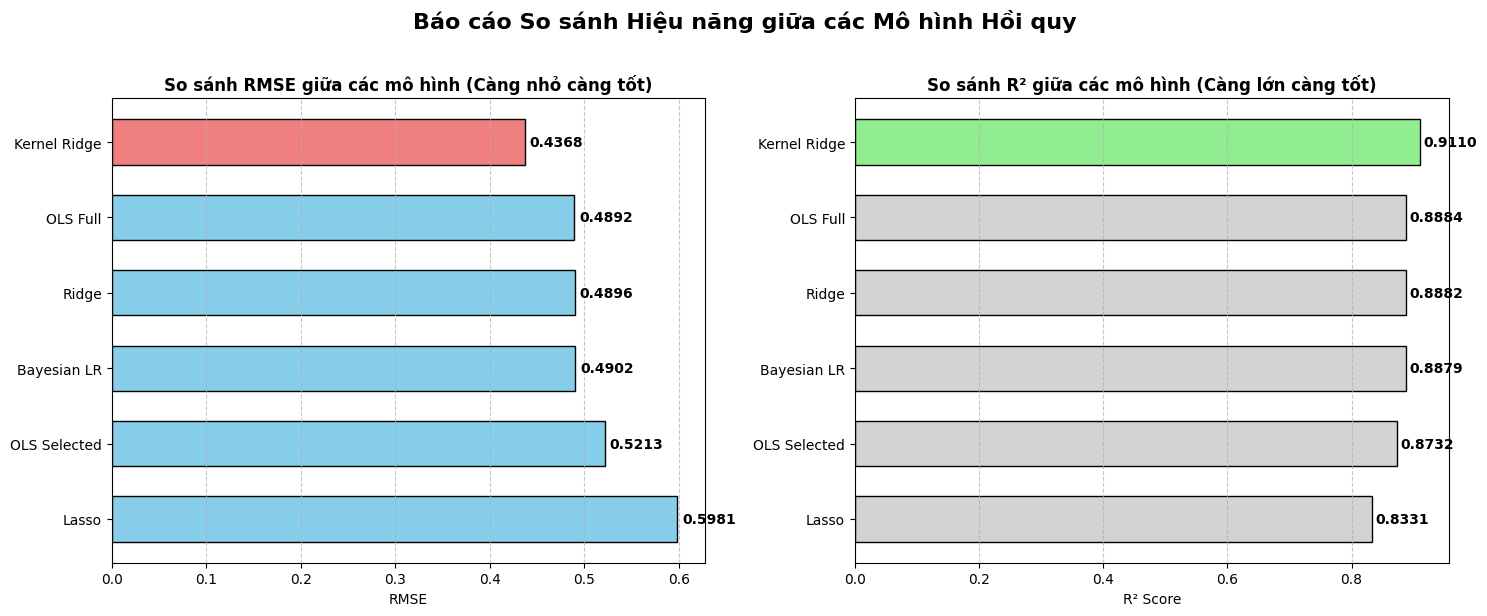

In [28]:
print("=== BẢNG TỔNG HỢP HIỆU NĂNG CÁC MÔ HÌNH TRÊN TẬP TEST ===")
df_comparison = comparator.compare_models()
display(df_comparison)

comparator.plot_model_comparison()

**Nhận xét kết quả mô hình:**
* Dựa vào biểu đồ và bảng metrics, mô hình phi tuyến Kernel Ridge Regression cho hiệu năng vượt trội nhất với $R^2$ cao nhất (0.9110) và RMSE thấp nhất. 
* Trong nhóm các mô hình tuyến tính, OLS Full, Ridge và Bayesian LR có hiệu năng gần như tương đương nhau ($R^2 \approx 0.888$). Tuy nhiên, nếu xét trong nhóm các mô hình tuyến tính, Ridge Regression mới chính là mô hình tốt nhất và mang tính thực tiễn cao nhất, là mô hình tuyến tính tối ưu nhất. Dù $R^2 \approx 0.8882$ (bám sát nút OLS Full), Ridge khắc phục hoàn toàn lỗi đa cộng tuyến của bộ dữ liệu cảm biến nhờ điều chuẩn $L_2$. Việc này giúp hệ số $\beta$ cực kỳ ổn định, dễ giải thích và phù hợp triển khai thực tế trên phần cứng IoT. 
* Mô hình Lasso có hiệu năng thấp nhất do tính chất chuẩn hóa L1 đã triệt tiêu mạnh tay nhiều đặc trưng để tạo ra một mô hình thưa (sparse), đánh đổi độ chính xác lấy sự đơn giản.

## 7. Phân tích Độ quan trọng của Đặc trưng (Feature Importance)
Trực quan hóa các hệ số hồi quy (Coefficients) sau khi đã chuẩn hóa.

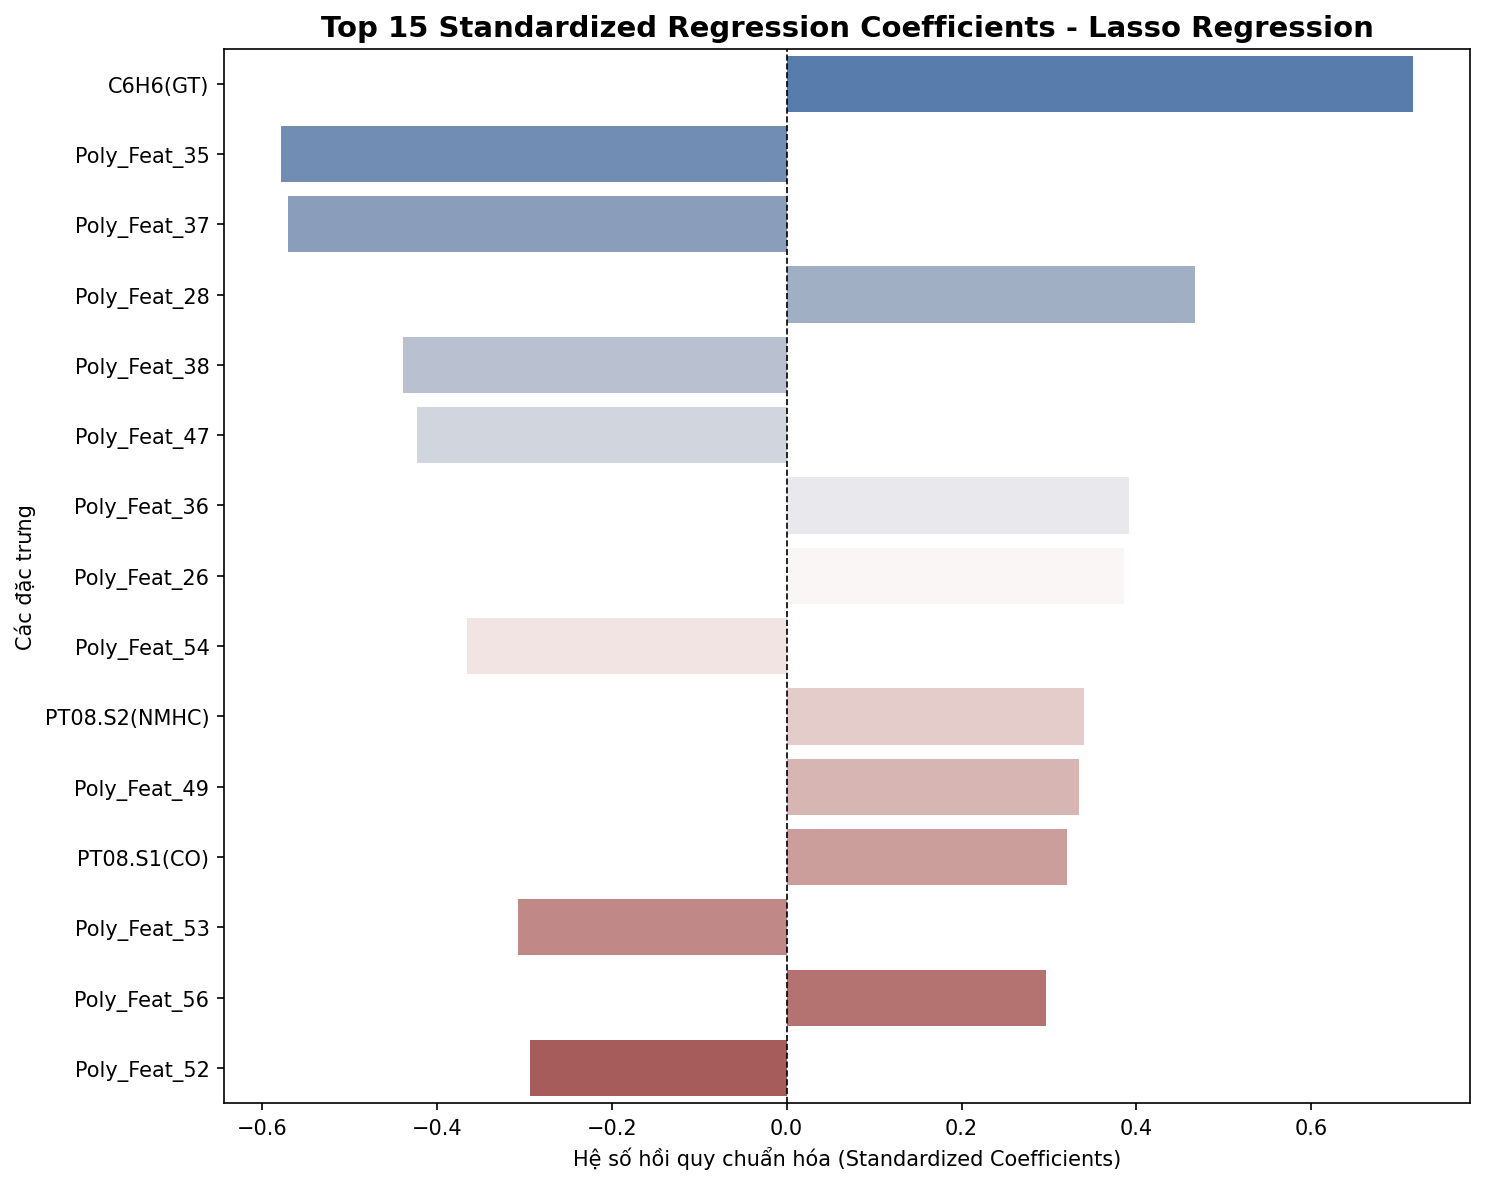

In [29]:
p_total = len(comparator.X_train[0])
feature_names_poly = [
    comparator.feature_names[j] if j < len(comparator.feature_names) else f'Poly_Feat_{j+1}' 
    for j in range(p_total)
]

lasso_model_dict = comparator.results['Lasso']['result']

EDAToolkit.plot_feature_importance(
    model=lasso_model_dict, 
    feature_names=feature_names_poly, 
    model_name="Lasso Regression"
)

**Kết luận từ Feature Importance:** Dựa vào biểu đồ, biến C6H6(GT) (nồng độ Benzene) và các tương tác đa thức của nó đóng vai trò tiên quyết và có trọng số lớn nhất trong việc dự đoán CO(GT). Điều này hoàn toàn hợp lý về mặt môi trường học: trong khu vực đô thị, cả CO và Benzene đều có chung nguồn phát thải chính là khí thải từ các phương tiện giao thông. Khí thải tăng làm cả hai khí cùng tăng, tạo ra độ tương quan tuyến tính rất cao, biến C6H6 trở thành "kim chỉ nam" dự báo CO chính xác nhất. Đứng ở các vị trí tiếp theo mới là các cảm biến chuyên dụng (như PT08.S1) và các yếu tố khí hậu để hỗ trợ tinh chỉnh sai số.

## 8. Chẩn đoán Phần dư (Residual Analysis) & Kiểm định Gauss-Markov

Vẽ biểu đồ chẩn đoán (Diagnostic Plots) và chạy kiểm định:
* **Shapiro-Wilk Test:** Kiểm tra phần dư có phân phối Chuẩn hay không.
* **Breusch-Pagan Test:** Kiểm tra phương sai phần dư có đồng nhất (Homoscedasticity) hay không.

=== PHÂN TÍCH PHẦN DƯ VÀ KIỂM ĐỊNH (Ridge) ===


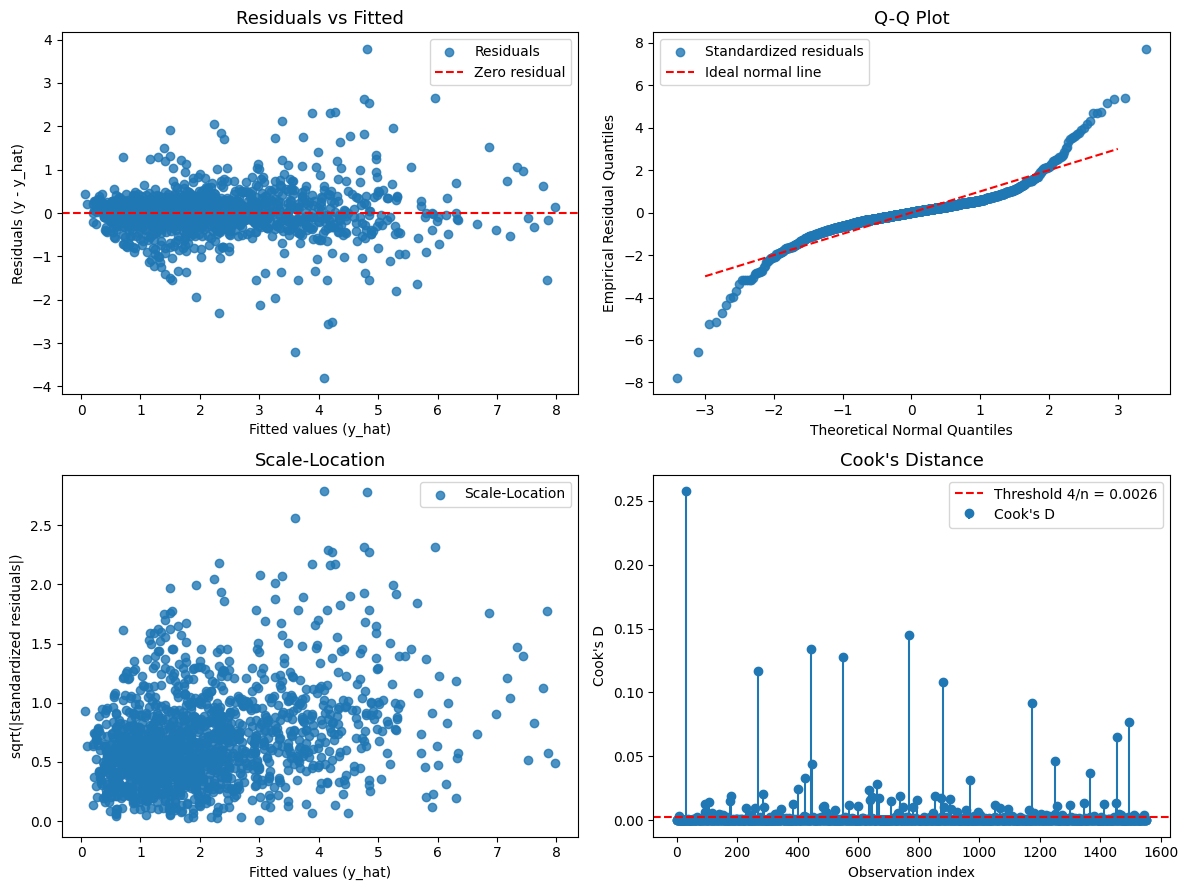


[Kiểm định Shapiro-Wilk (Tính chuẩn)]:
   + p-value = 6.7297e-36
   + Kết luận: KHÔNG ĐẠT (Phần dư lệch chuẩn)

[Kiểm định Breusch-Pagan (Phương sai đồng nhất)]:
   + p-value = 0.0000e+00
   + Kết luận: KHÔNG ĐẠT (Phương sai thay đổi / Heteroscedasticity)


In [30]:
diag_model_name = 'Ridge'
diag_result = comparator.results[diag_model_name]

print(f"=== PHÂN TÍCH PHẦN DƯ VÀ KIỂM ĐỊNH ({diag_model_name}) ===")
y_test_pred = diag_result['y_pred']
y_test_true = comparator.y_test
X_test_plot = comparator.X_test

fig, metrics = residual_diagnostics(y_test_true, y_test_pred, X_test_plot)

sw_test = comparator.shapiro_wilk_test(diag_result['residuals'])
print(f"\n[Kiểm định Shapiro-Wilk (Tính chuẩn)]:")
print(f"   + p-value = {sw_test['p_value']:.4e}")
print(f"   + Kết luận: {'ĐẠT (Phần dư phân phối chuẩn)' if sw_test['is_normal'] else 'KHÔNG ĐẠT (Phần dư lệch chuẩn)'}")

bp_test = comparator.breusch_pagan_test(comparator.X_test, diag_result['residuals'])
print(f"\n[Kiểm định Breusch-Pagan (Phương sai đồng nhất)]:")
print(f"   + p-value = {bp_test['p_value']:.4e}")
print(f"   + Kết luận: {'ĐẠT (Đồng phương sai)' if bp_test['is_homoscedastic'] else 'KHÔNG ĐẠT (Phương sai thay đổi / Heteroscedasticity)'}")

**Lưu ý:** Dù Kernel Ridge có hiệu năng dự báo cao nhất, nhưng do sử dụng hàm kernel ánh xạ phi tuyến, các công cụ chẩn đoán phần dư và kiểm định truyền thống (OLS-like) không còn phù hợp về mặt toán học. Do đó, nhóm quyết định sử dụng Ridge (mô hình tuyến tính tối ưu nhất) để thực hiện chẩn đoán, nhằm đảm bảo các đại lượng kiểm định và khoảng cách hình học giữ nguyên được ý nghĩa thống kê.

## 9. Kết luận chung
Đối chiếu kết quả của các mô hình Data Fitting với ngữ cảnh thực tế của bộ dữ liệu AirQualityUCI, nhóm rút ra các kết luận sau:
* **Đặc thù dữ liệu môi trường:** Dữ liệu cảm biến đo chất lượng không khí ngoài trời chịu ảnh hưởng rất mạnh bởi các yếu tố nhiễu (như nhiệt độ, độ ẩm tuyệt đối) và có tỉ lệ khuyết/ngoại lai cao. Quá trình xây dựng Data Pipeline cẩn thận (giới hạn ngoại lai bằng Winsorize, điền khuyết bằng KNN) là nhân tố quyết định giúp mô hình OLS không bị sai lệch.
* **Sự tương quan vật lý (Feature Importance):** Kết quả từ mô hình Lasso chỉ ra rằng nồng độ Benzene (C6H6) và cảm biến oxit kim loại (PT08.S1) là các biến dự báo mạnh mẽ nhất cho CO. Điều này hoàn toàn chính xác với tính chất hóa học môi trường, vì cả CO và Benzene tại các đô thị đều chung một nguồn phát thải chính là khí thải giao thông.
* **Lựa chọn mô hình tối ưu:** Các mô hình có điều chuẩn (Ridge, Lasso) cho thấy sự ổn định hơn OLS thuần túy khi đối mặt với hiện tượng đa cộng tuyến của cảm biến. Mặc dù Kernel Ridge Regression cho hiệu năng dự đoán cao nhất ($R^2 > 0.91$), nhưng nếu xét trên khía cạnh triển khai vào các trạm quan trắc IoT yêu cầu tính toán nhanh và dễ giải thích, mô hình Ridge Linear vẫn là sự cân bằng hoàn hảo nhất giữa độ chính xác và tính đơn giản.